In [5]:
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\Rohan Ankam\OneDrive\Desktop\Raw Data\job_salary_prediction_dataset.csv")

In [9]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


Null values if any

In [8]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [9]:
df.dtypes

job_title           object
experience_years     int64
education_level     object
skills_count         int64
industry            object
company_size        object
location            object
remote_work         object
certifications       int64
salary               int64
dtype: object

In [13]:
y = []

for i in range(len(df)):
    x = tuple(df.iloc[i])
    y.append(x)

y

[('AI Engineer',
  10,
  'Bachelor',
  2,
  'Healthcare',
  'Medium',
  'India',
  'Hybrid',
  2,
  109413),
 ('Data Analyst',
  5,
  'Bachelor',
  17,
  'Telecom',
  'Small',
  'Australia',
  'No',
  0,
  93764),
 ('Frontend Developer',
  18,
  'PhD',
  4,
  'Media',
  'Medium',
  'Singapore',
  'No',
  1,
  148123),
 ('Business Analyst',
  19,
  'PhD',
  13,
  'Retail',
  'Medium',
  'Canada',
  'Yes',
  0,
  189123),
 ('Product Manager',
  15,
  'Bachelor',
  7,
  'Manufacturing',
  'Large',
  'Sweden',
  'Yes',
  0,
  165069),
 ('AI Engineer',
  0,
  'High School',
  4,
  'Education',
  'Enterprise',
  'USA',
  'No',
  2,
  180351),
 ('Backend Developer',
  6,
  'High School',
  16,
  'Manufacturing',
  'Enterprise',
  'Canada',
  'No',
  3,
  165375),
 ('Machine Learning Engineer',
  4,
  'Bachelor',
  18,
  'Healthcare',
  'Enterprise',
  'Canada',
  'Hybrid',
  5,
  202463),
 ('AI Engineer',
  5,
  'Diploma',
  14,
  'Telecom',
  'Enterprise',
  'Singapore',
  'Yes',
  0,
  1718

In [15]:
job_salary_prediction_dataset = open('job_salary_prediction_dataset.txt', 'w')

for tuple in y:
    job_salary_prediction_dataset.write(str(tuple) + ',' + '\n')

job_salary_prediction_dataset.close()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [10]:
print(df.isnull().sum())

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


In [11]:
print(df['salary'].mean())

145718.080524


In [12]:
salary_by_exp = df.groupby('experience_years')['salary'].mean()
print(salary_by_exp)

experience_years
0     118872.622755
1     121250.527183
2     124228.943849
3     126921.603112
4     129688.783435
5     131787.250717
6     134898.296712
7     137560.810366
8     140667.762731
9     142763.834683
10    145771.972998
11    148133.173236
12    150779.033238
13    154082.616121
14    156413.152885
15    158981.141636
16    162290.866980
17    164282.181423
18    167421.185837
19    169797.362442
20    173179.709650
Name: salary, dtype: float64


In [14]:
print("Median:", np.median(df['salary']))
print("Std Dev:", np.std(df['salary']))

Median: 143453.0
Std Dev: 37407.87791326386


In [15]:
print("25th percentile:", np.percentile(df['salary'], 25))
print("75th percentile:", np.percentile(df['salary'], 75))

25th percentile: 119358.0
75th percentile: 169492.0


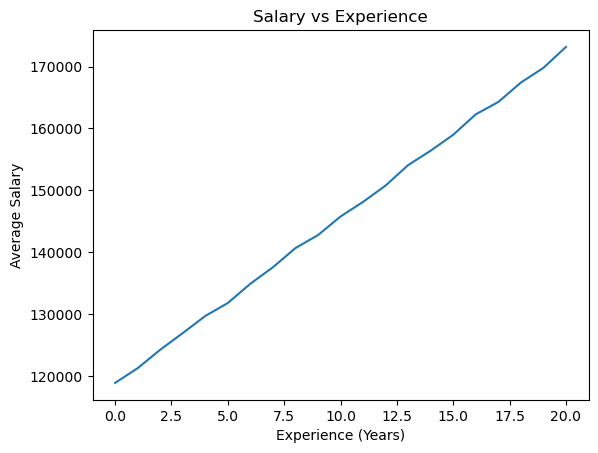

In [16]:
plt.figure()
plt.plot(salary_by_exp.index, salary_by_exp.values)
plt.title("Salary vs Experience")
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")
plt.show()

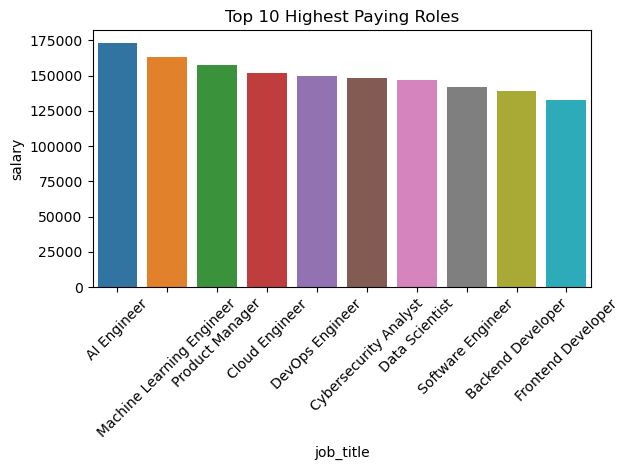

In [23]:
import seaborn as sns

top_roles = df.groupby('job_title')['salary'].mean().reset_index()
top_roles = top_roles.sort_values(by='salary', ascending=False).head(10)

plt.figure()
sns.barplot(x='job_title', y='salary', data=top_roles)
plt.xticks(rotation=45)
plt.title("Top 10 Highest Paying Roles")
plt.tight_layout()
plt.show()

C:\Users\Rohan Ankam\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


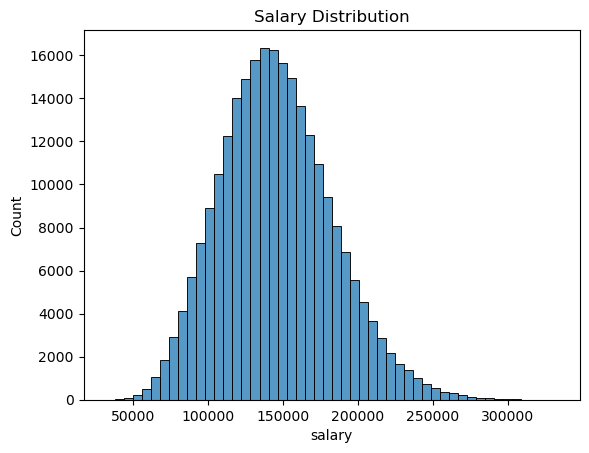

In [24]:
plt.figure()
sns.histplot(df['salary'], bins=50)
plt.title("Salary Distribution")
plt.show()

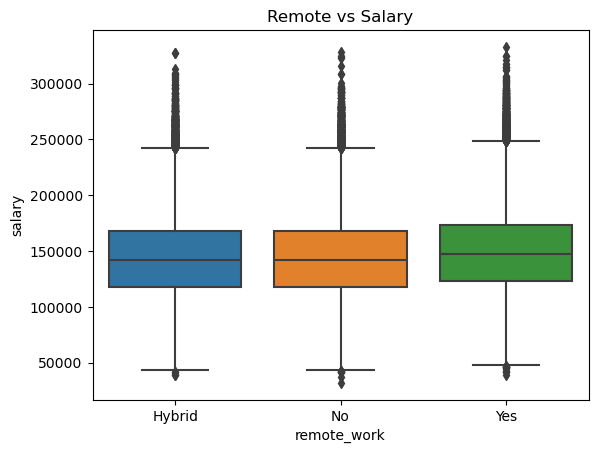

In [19]:
plt.figure()
sns.boxplot(x='remote_work', y='salary', data=df)
plt.title("Remote vs Salary")
plt.show()

In [20]:
avg_salary_by_role = df.groupby('job_title')['salary'].transform('mean')

df['anomaly'] = df['salary'] > 2 * avg_salary_by_role

print(df[df['anomaly'] == True].head())

               job_title  experience_years education_level  skills_count  \
1191    Business Analyst                18             PhD            15   
4923   Backend Developer                20             PhD            15   
12701   Business Analyst                19             PhD             9   
23699   Business Analyst                18             PhD            18   
28626    DevOps Engineer                20             PhD            17   

         industry company_size location remote_work  certifications  salary  \
1191   Healthcare   Enterprise      USA         Yes               3  246080   
4923   Government   Enterprise      USA          No               5  278642   
12701      Retail   Enterprise      USA         Yes               5  250913   
23699       Media   Enterprise      USA         Yes               3  250625   
28626      Retail   Enterprise      USA         Yes               4  304968   

       anomaly  
1191      True  
4923      True  
12701     True  


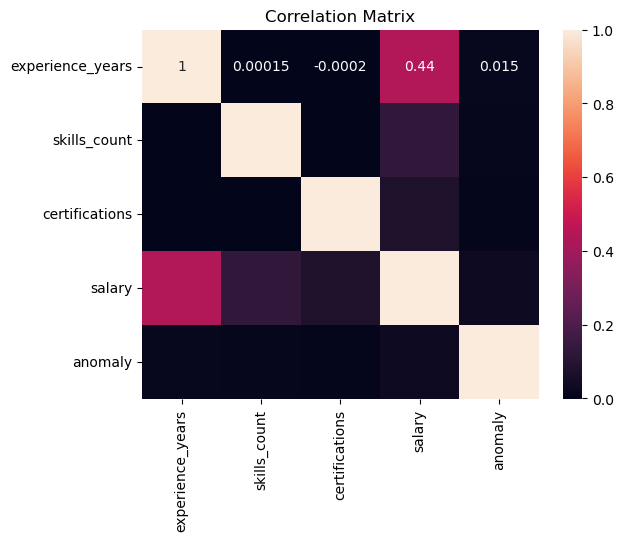

In [21]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [26]:
top_industries = df.groupby('industry')['salary'].mean().sort_values(ascending=False).head(10)

print(top_industries)

industry
Education        145993.564547
Media            145891.271071
Telecom          145876.511967
Technology       145863.808377
Finance          145801.639468
Healthcare       145759.995702
Government       145613.869242
Manufacturing    145530.603301
Consulting       145451.638293
Retail           145399.699408
Name: salary, dtype: float64


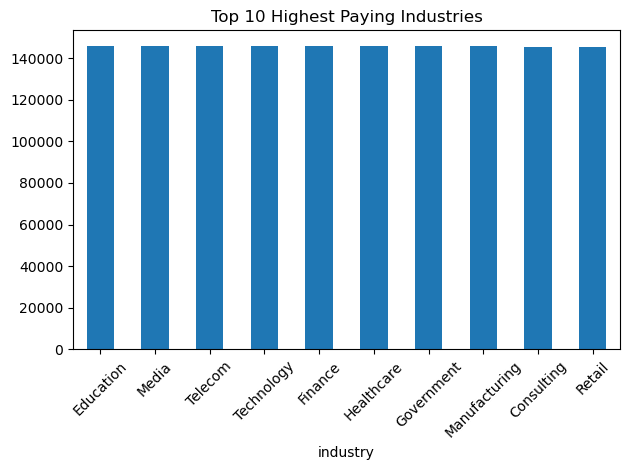

In [27]:
plt.figure()
top_industries.plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Top 10 Highest Paying Industries")
plt.tight_layout()
plt.show()

In [28]:
salary_exp = df.groupby('experience_years')['salary'].mean()

growth = salary_exp.pct_change() * 100
print(growth)

experience_years
0          NaN
1     2.000380
2     2.456415
3     2.167498
4     2.180228
5     1.618079
6     2.360658
7     1.973719
8     2.258603
9     1.490087
10    2.107073
11    1.619790
12    1.786136
13    2.191009
14    1.512524
15    1.641798
16    2.081835
17    1.227003
18    1.910739
19    1.419281
20    1.991990
Name: salary, dtype: float64


In [29]:
pivot_table = pd.pivot_table(
    df,
    values='salary',
    index='job_title',
    columns='education_level',
    aggfunc='mean'
)

print(pivot_table.head())

education_level             Bachelor        Diploma    High School  \
job_title                                                            
AI Engineer            170325.172840  164761.709430  159405.097602   
Backend Developer      136614.184494  130268.433810  125834.239761   
Business Analyst       118757.515568  114278.810578  108158.165659   
Cloud Engineer         148710.516913  143830.074029  138073.935264   
Cybersecurity Analyst  145162.414634  140337.383298  134647.767206   

education_level               Master            PhD  
job_title                                            
AI Engineer            181456.012882  191768.582611  
Backend Developer      146391.306485  157716.068847  
Business Analyst       130140.376596  141037.628896  
Cloud Engineer         160326.730580  170478.571816  
Cybersecurity Analyst  156363.320869  166825.398893  


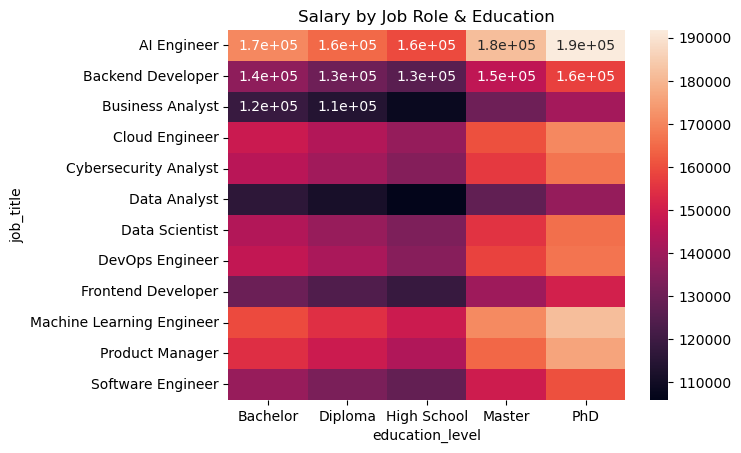

In [30]:
plt.figure()
sns.heatmap(pivot_table, annot=True)
plt.title("Salary by Job Role & Education")
plt.show()

In [31]:
threshold = df['salary'].quantile(0.90)

top_earners = df[df['salary'] >= threshold]

print(top_earners.head())

                    job_title  experience_years education_level  skills_count  \
7   Machine Learning Engineer                 4        Bachelor            18   
38  Machine Learning Engineer                15             PhD            15   
43  Machine Learning Engineer                15     High School            15   
69          Software Engineer                 6          Master            16   
73            DevOps Engineer                 9             PhD             4   

      industry company_size location remote_work  certifications  salary  \
7   Healthcare   Enterprise   Canada      Hybrid               5  202463   
38  Consulting       Medium  Germany      Hybrid               5  213920   
43  Technology   Enterprise  Germany         Yes               2  212249   
69      Retail        Large      USA         Yes               4  200988   
73  Healthcare   Enterprise       UK         Yes               1  208215   

    anomaly  
7     False  
38    False  
43    False  


In [32]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['salary'] < Q1 - 1.5 * IQR) | (df['salary'] > Q3 + 1.5 * IQR)]

print(outliers.head())

                     job_title  experience_years education_level  \
124           Business Analyst                 0     High School   
159                AI Engineer                 6          Master   
453               Data Analyst                 6     High School   
536  Machine Learning Engineer                18             PhD   
628                AI Engineer                18         Diploma   

     skills_count    industry company_size location remote_work  \
124             8     Finance        Small    India          No   
159            18  Healthcare   Enterprise      USA         Yes   
453             1  Healthcare        Small    India      Hybrid   
536             4  Consulting   Enterprise   Canada          No   
628            14  Government        Large      USA         Yes   

     certifications  salary  anomaly  
124               2   43673    False  
159               2  257220    False  
453               1   41404    False  
536               4  271175    F

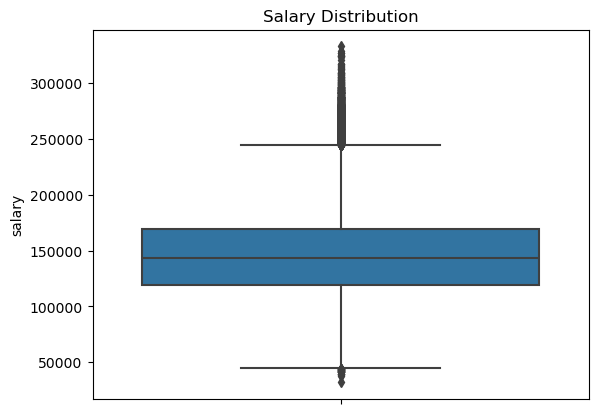

In [33]:
plt.figure()
sns.boxplot(y=df['salary'])
plt.title("Salary Distribution")
plt.show()

In [34]:
df['salary_per_skill'] = df['salary'] / df['skills_count']

print(df[['salary', 'skills_count', 'salary_per_skill']].head())

   salary  skills_count  salary_per_skill
0  109413             2      54706.500000
1   93764            17       5515.529412
2  148123             4      37030.750000
3  189123            13      14547.923077
4  165069             7      23581.285714


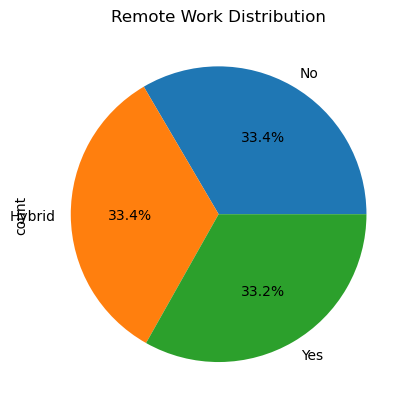

In [35]:
remote_count = df['remote_work'].value_counts()

plt.figure()
remote_count.plot(kind='pie', autopct='%1.1f%%')
plt.title("Remote Work Distribution")
plt.show()

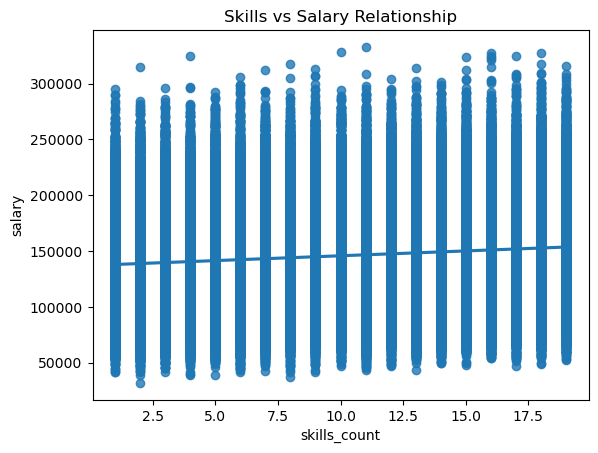

In [38]:
sns.regplot(x='skills_count', y='salary', data=df)
plt.title("Skills vs Salary Relationship")
plt.show()